# Feature Engineering

## Table of Contents

----

## Requirements

In [44]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import emd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

## Timeframe Refining & Train-Test Split

In [9]:
data = pd.read_csv('../data/raw/dataset_2019_2025.csv')
data['datetime'] = pd.to_datetime(data['datetime'], utc=True)
data = data[data['datetime'].dt.year >= 2022]
data.to_csv('../data/raw/dataset_2022_2025.csv', index=False)
tmp_data = data[data['datetime'].dt.year >= 2023]
tmp_len = len(tmp_data)

train_data = tmp_data.iloc[:int(np.floor(tmp_len*0.9))]
cols = [
    'datetime', 'price',
    'precipitation', 'cloud_cover', 'temperature', 'relative_humidity',
    'renewable_share_of_load', 'load',
    'sum_cbet'
]
train_data = train_data[cols]
print(train_data.shape)
train_data.head()

(15789, 9)


,datetime,price,precipitation,cloud_cover,temperature,relative_humidity,renewable_share_of_load,load,sum_cbet
35064,2023-01-01 00:00:00+00:00,-1.07,0.0,100.00,14.925,54.75,101.5,37277.4,-16.357
35065,2023-01-01 01:00:00+00:00,-1.47,0.0,100.00,14.450,55.00,99.9,36371.1,-14.008
35066,2023-01-01 02:00:00+00:00,-5.08,0.0,96.75,14.200,56.00,98.7,35625.3,-14.542
35067,2023-01-01 03:00:00+00:00,-4.49,0.0,93.75,13.800,58.50,100.6,35655.0,-13.618
35068,2023-01-01 04:00:00+00:00,-5.40,0.0,87.50,13.650,59.50,100.9,35195.6,-13.729


## Empirical Mode Decomposition (EMD)

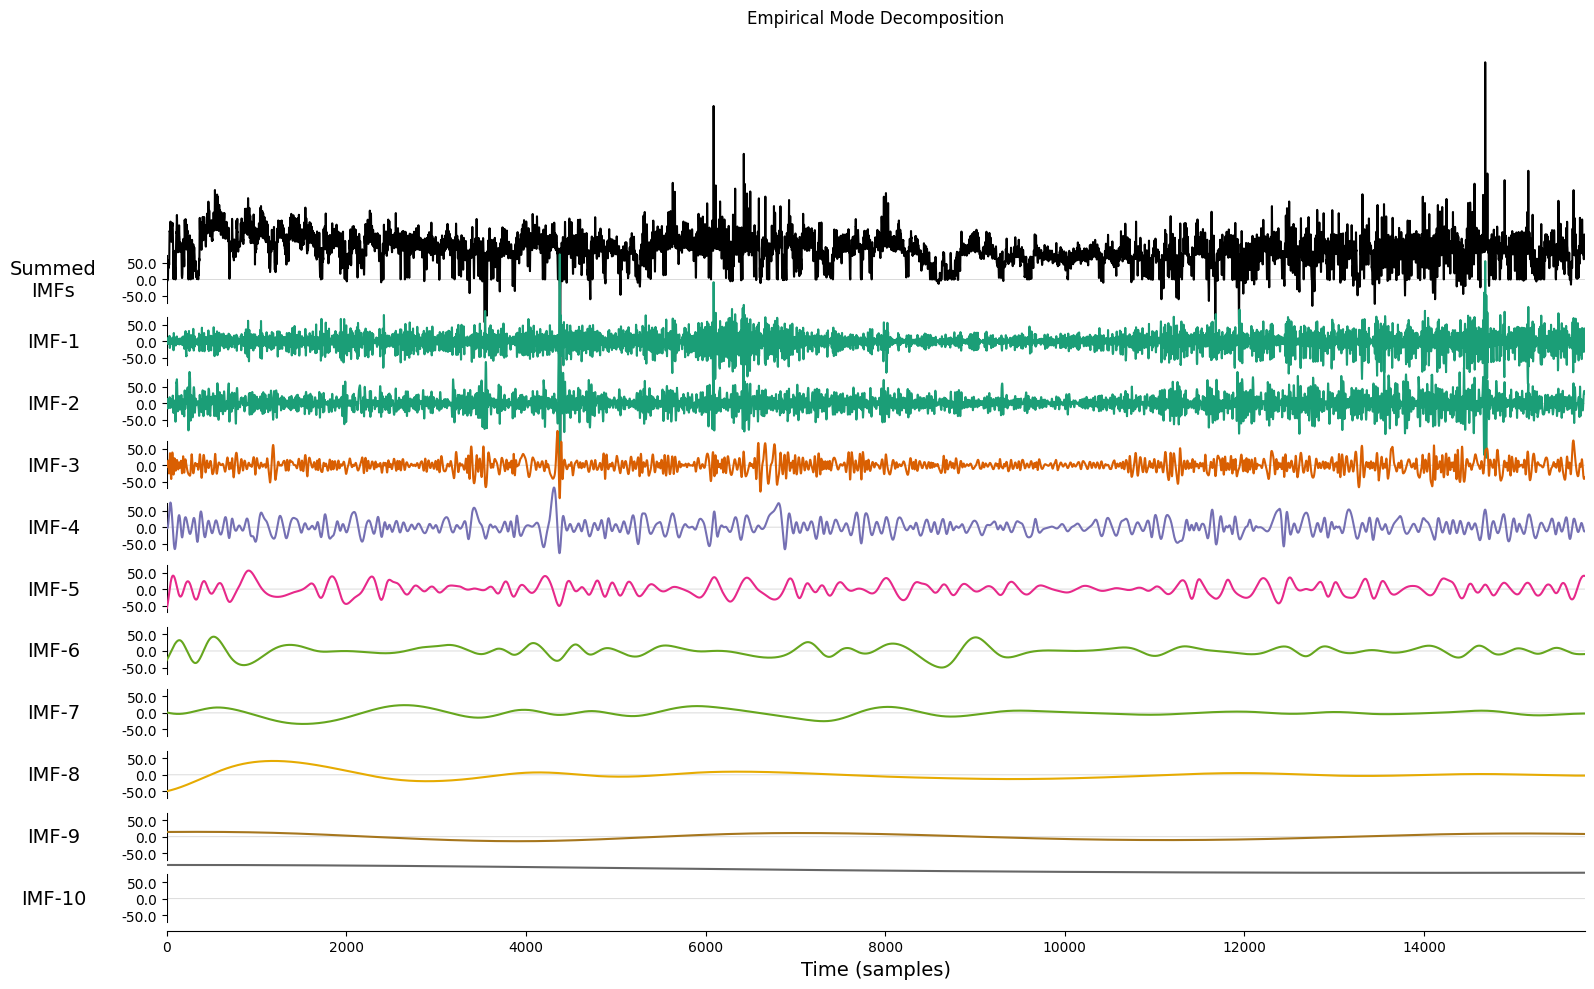

In [19]:
## These are the "regular" IMFs generated by EMD
### No clear mode mixing present
### (only insubstantial evidence of mode mixing for IMF-1/2/3)

price = train_data['price'].to_numpy()
imfs = emd.sift.sift(price)
emd.plotting.plot_imfs(imfs)
plt.title('Empirical Mode Decomposition')
plt.tight_layout()
plt.show()

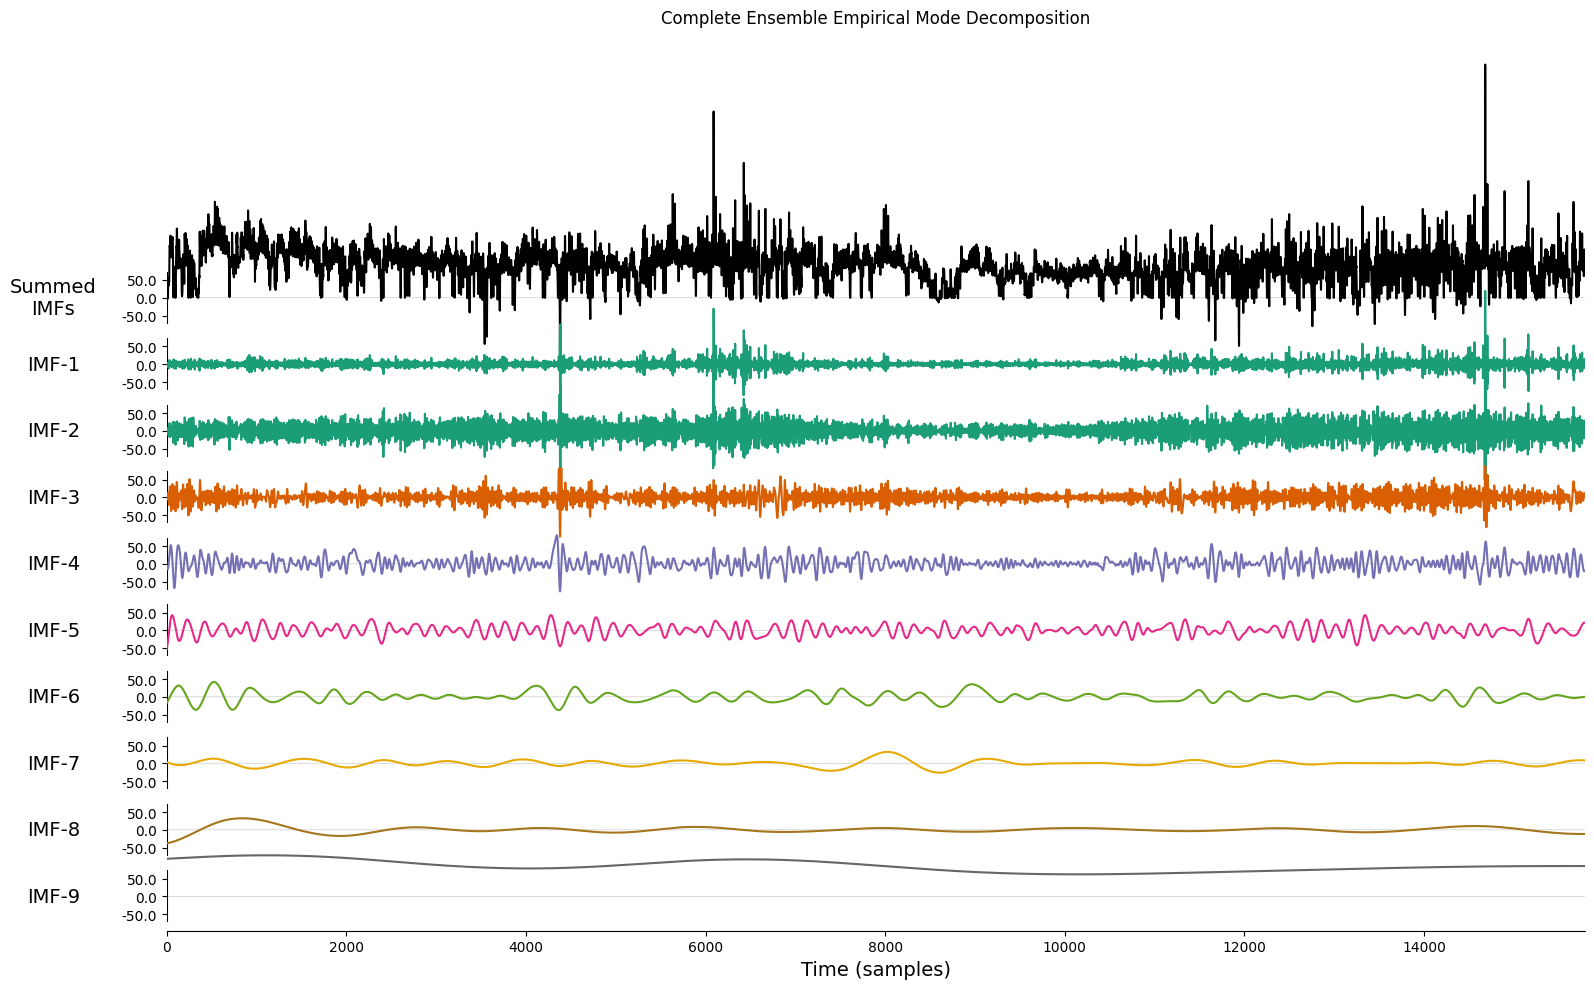

In [ ]:
## Complete Ensemble IMFs
### Slight improvement in preventing mode mixing

ce_imfs = emd.sift.complete_ensemble_sift(price, max_imfs=7, nensembles=16, noise_seed=0)
emd.plotting.plot_imfs(ce_imfs)
plt.title('Complete Ensemble Empirical Mode Decomposition')
plt.tight_layout()
plt.show()

In [40]:
train_data_imf1 = train_data.copy(deep=True)
train_data_imf1['price_imf1'] = ce_imfs[:, 0]

train_data_imf2 = train_data.copy(deep=True)
train_data_imf2['price_imf2'] = ce_imfs[:, 1]

train_data_imf3 = train_data.copy(deep=True)
train_data_imf3['price_imf3'] = ce_imfs[:, 2]

train_data_imf4 = train_data.copy(deep=True)
train_data_imf4['price_imf4'] = ce_imfs[:, 3]

train_data_imf5 = train_data.copy(deep=True)
train_data_imf5['price_imf5'] = ce_imfs[:, 4]

train_data_imf6 = train_data.copy(deep=True)
train_data_imf6['price_imf6'] = ce_imfs[:, 5]

train_data_imf7 = train_data.copy(deep=True)
train_data_imf7['price_imf7'] = ce_imfs[:, 6]

train_data_imf8 = train_data.copy(deep=True)
train_data_imf8['price_imf8'] = ce_imfs[:, 7]

train_data_imf9 = train_data.copy(deep=True)
train_data_imf9['price_imf9'] = ce_imfs[:, 8]

train_datasets = [train_data_imf1, train_data_imf2, train_data_imf3, train_data_imf4, train_data_imf5, train_data_imf6, train_data_imf7, train_data_imf8, train_data_imf9]

## Lagged Feature Selection

### Lagged Target Variables Selection

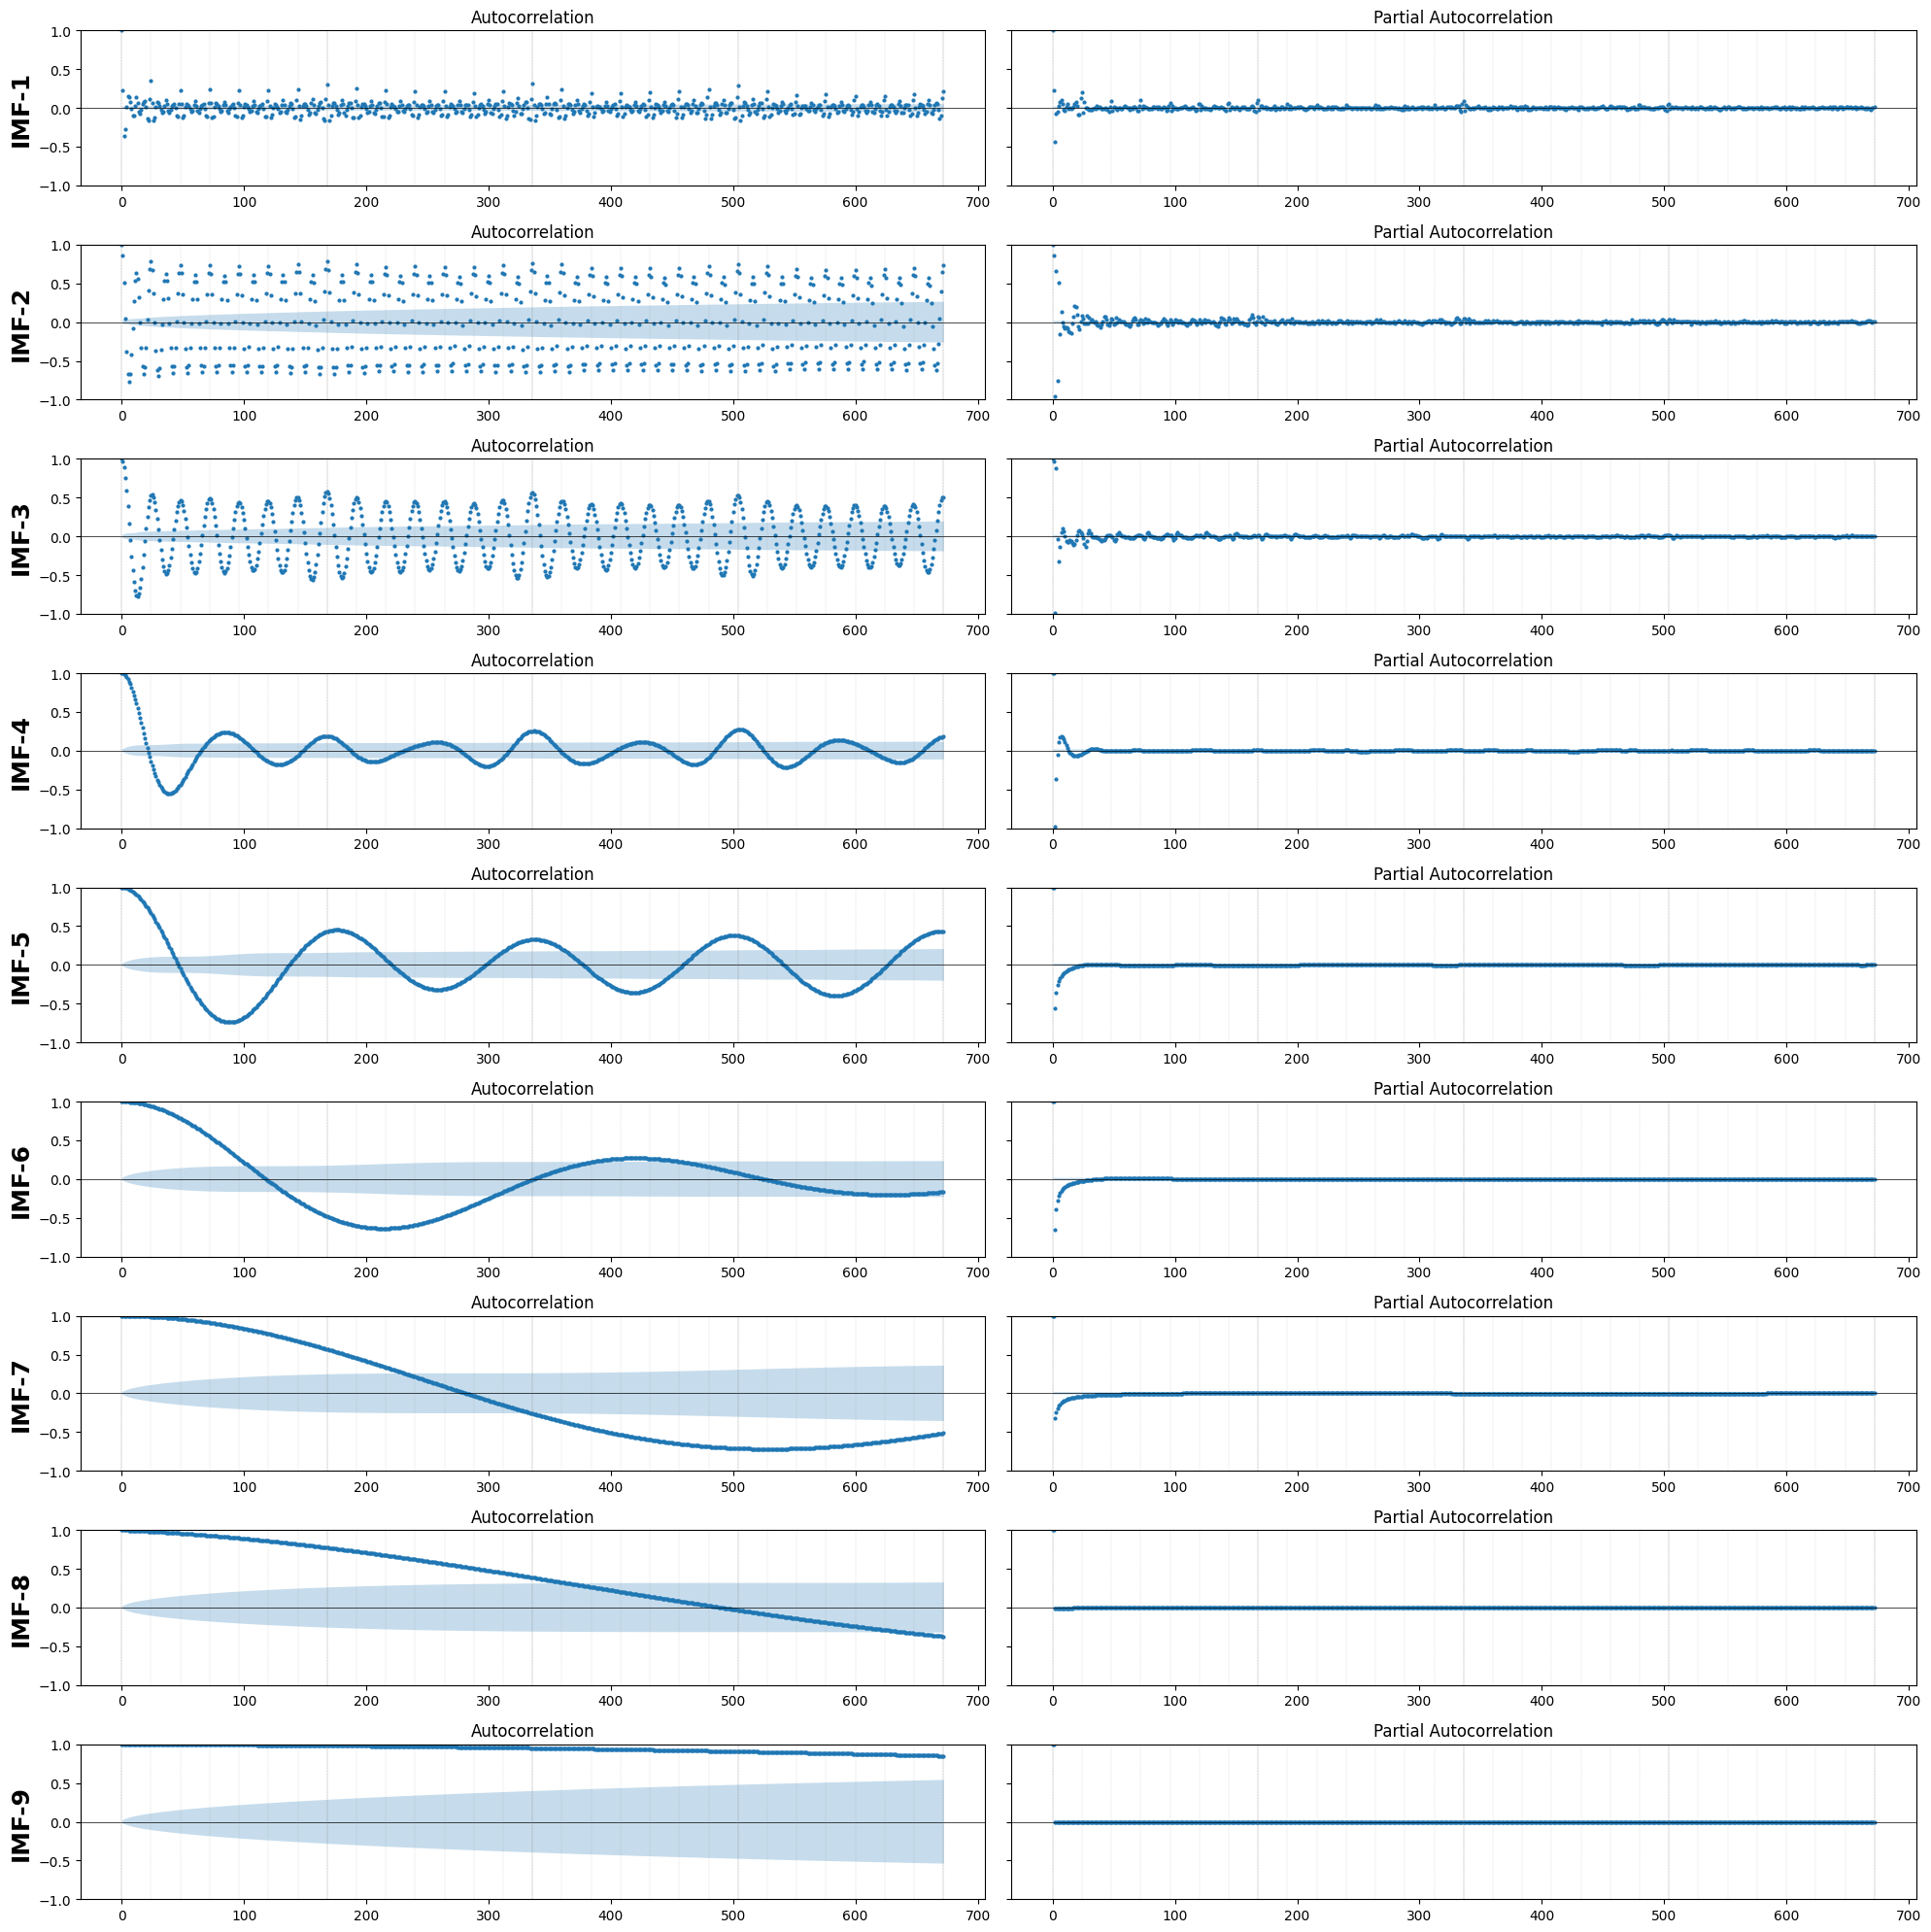

In [ ]:
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(20, 20), sharey=True)

for row, dataset in enumerate(train_datasets):
    ax0, ax1 = axes[row][0], axes[row][1]

    plot_acf(x=dataset[f'price_imf{row+1}'], ax=ax0, lags=24*7*4, use_vlines=False, markersize=2)
    ax0.axhline(0, color='black', linewidth=0.5)
    ax0.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax0.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
    ax0.set_ylabel(f'IMF-{row+1}', fontweight='bold', fontsize=18)

    plot_pacf(x=dataset[f'price_imf{row+1}'], ax=ax1, lags=24*7*4, use_vlines=False, markersize=2)
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
    ax1.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')

fig.tight_layout()
plt.show()

In [42]:
# lagged targets for IMF-1
for l in [_ for _ in range(12, 24)] + [_ for _ in range(24, 24*7, 24)] + [_ for _ in range(24*7, 24*7*4, 24*7)]:
    train_data_imf1.loc[:, f'price_imf1_l{l}'] = train_data_imf1.loc[:, 'price_imf1'].shift(l)

# lagged targets for IMF-2
for l in [_ for _ in range(12, 24)] + [_ for _ in range(24*7, 24*7*2, 24*7)]:
    train_data_imf2.loc[:, f'price_imf2_l{l}'] = train_data_imf2.loc[:, 'price_imf2'].shift(l)

# lagged targets for IMF-3
for l in [_ for _ in range(12, 24)] + [_ for _ in range(24, 24*7, 24)]:
    train_data_imf3.loc[:, f'price_imf3_l{l}'] = train_data_imf3.loc[:, 'price_imf3'].shift(l)

### Lagged Exogenous Variables Selection

#### IMF-1

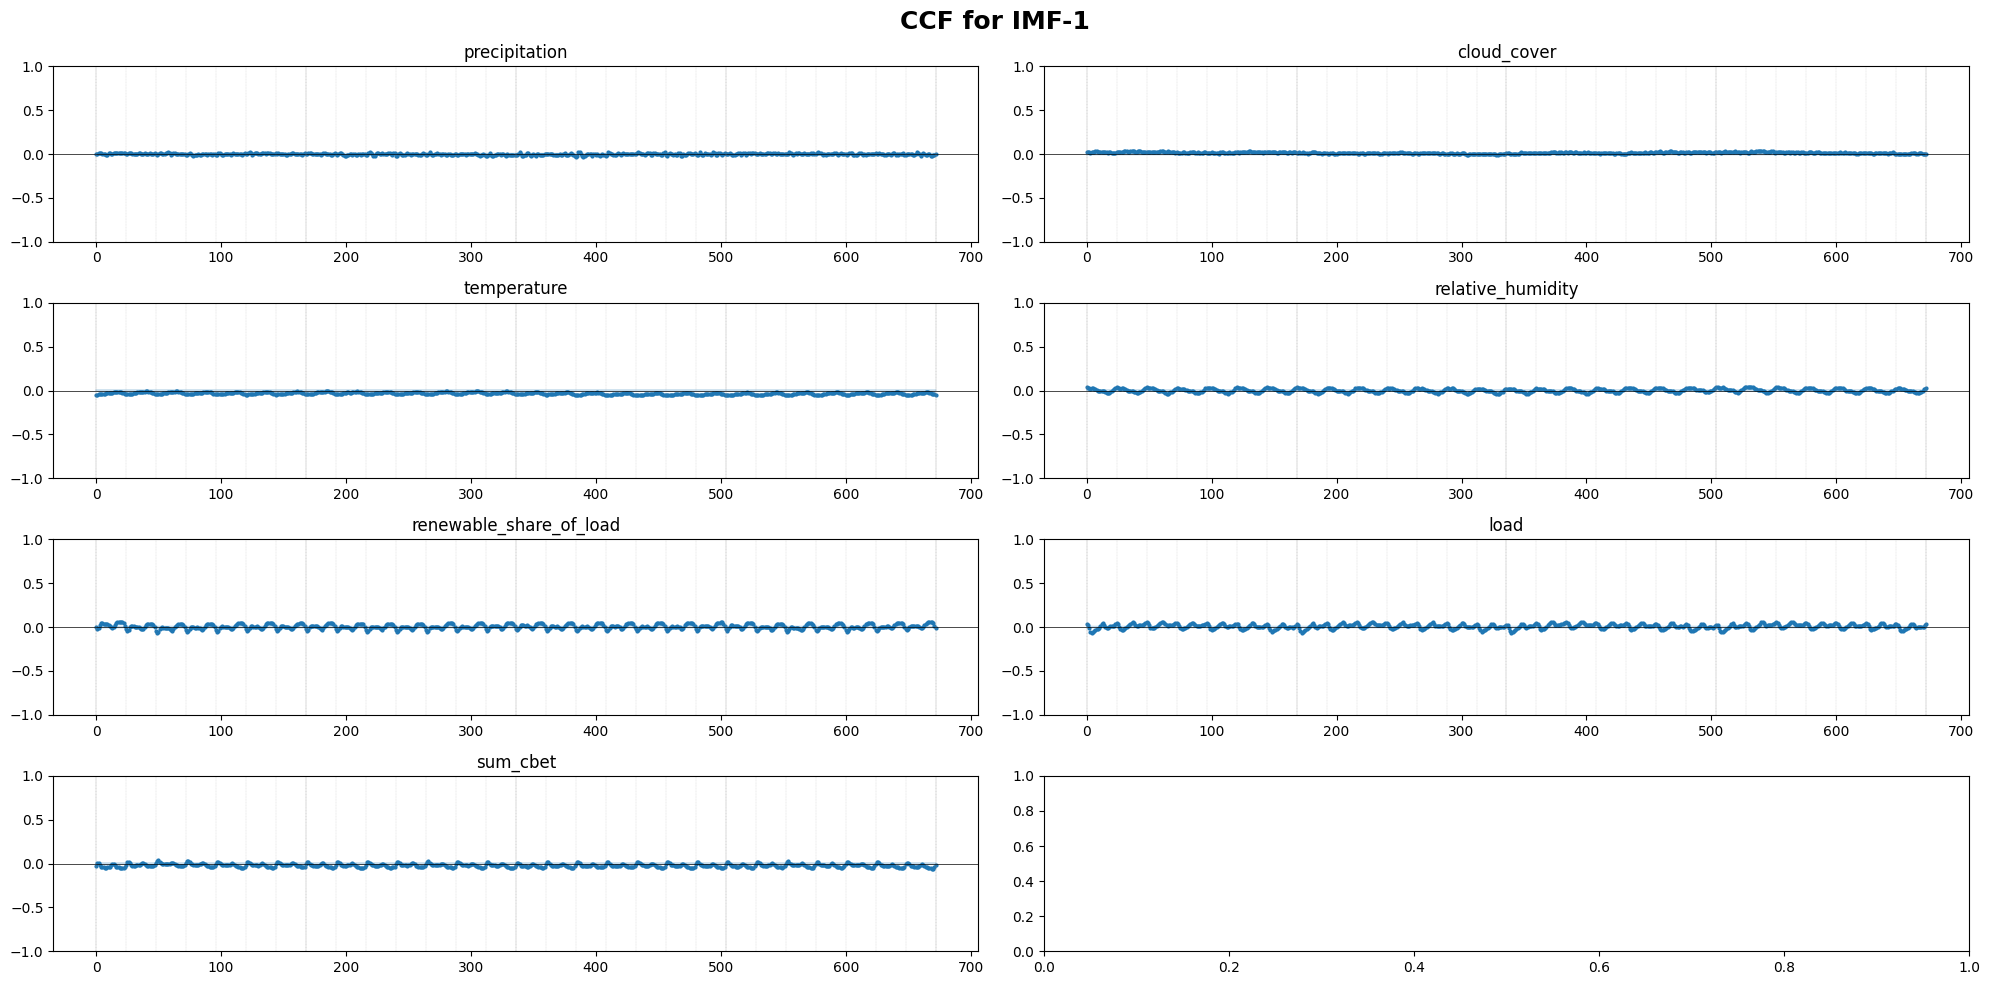

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


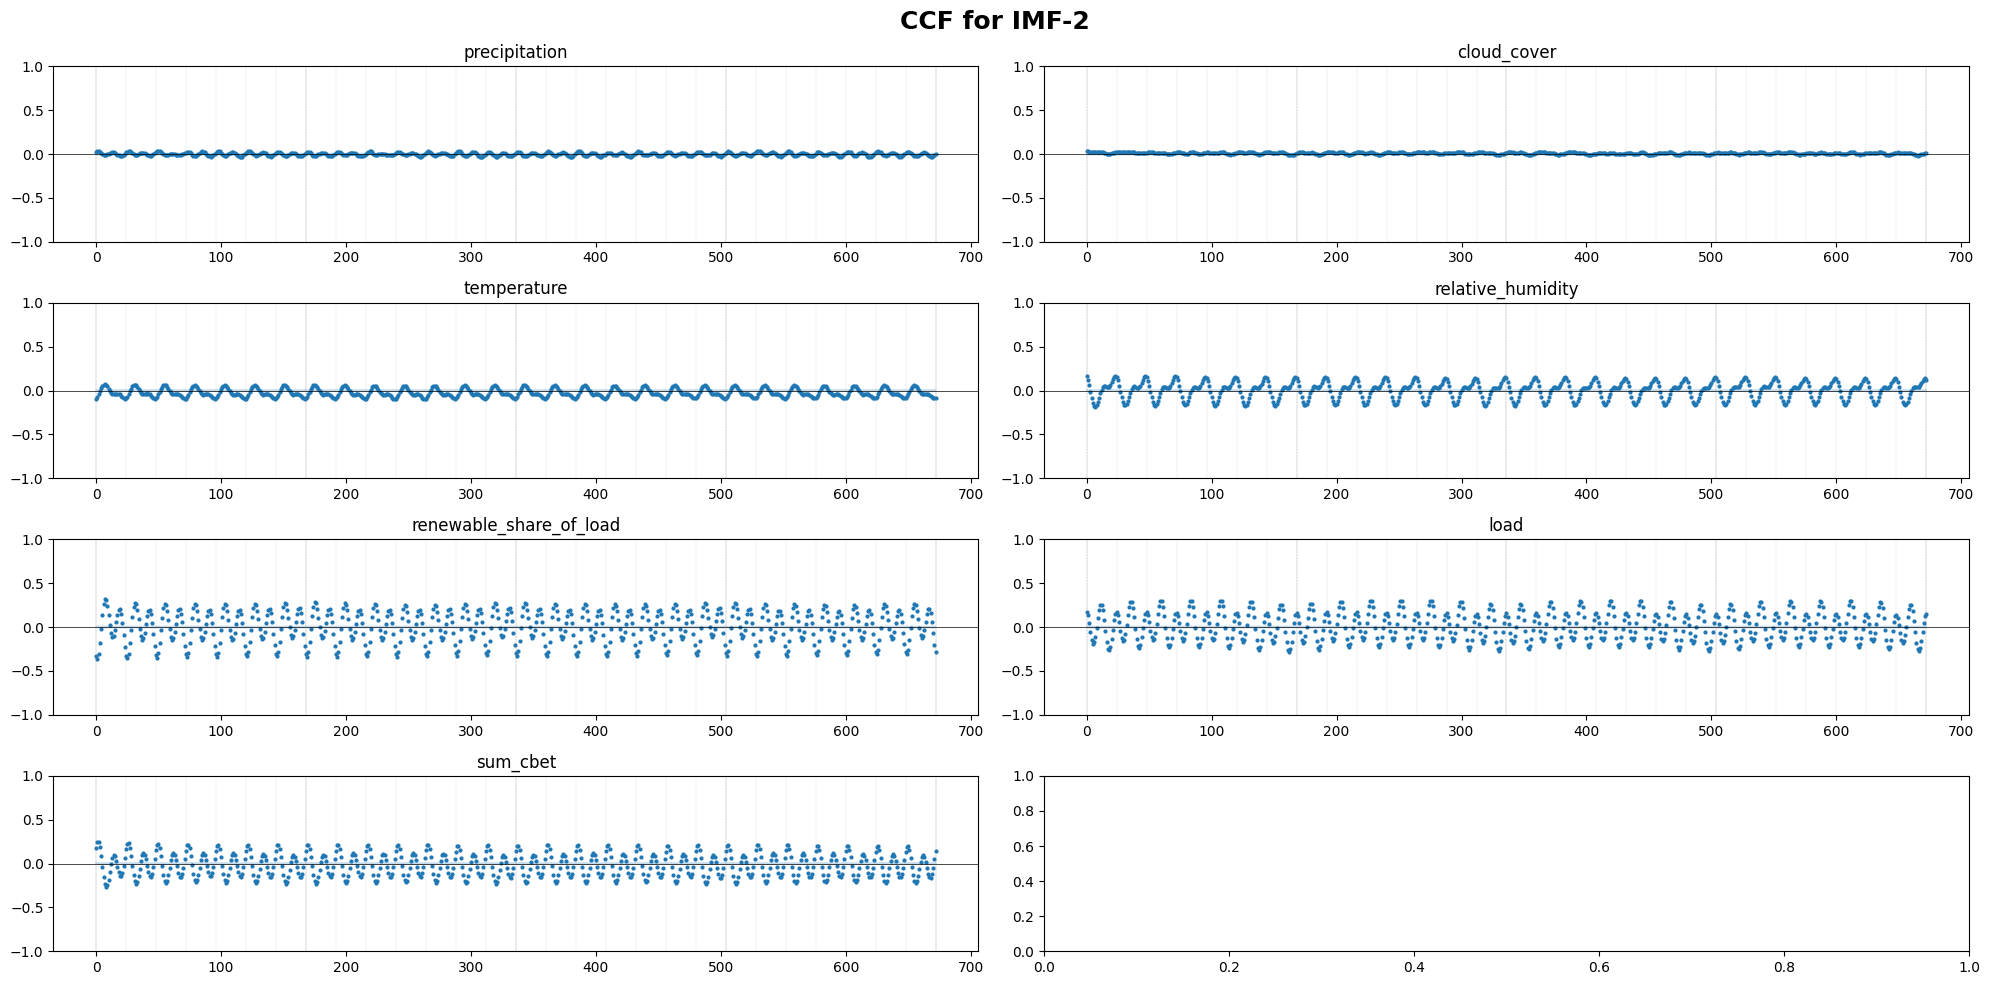

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


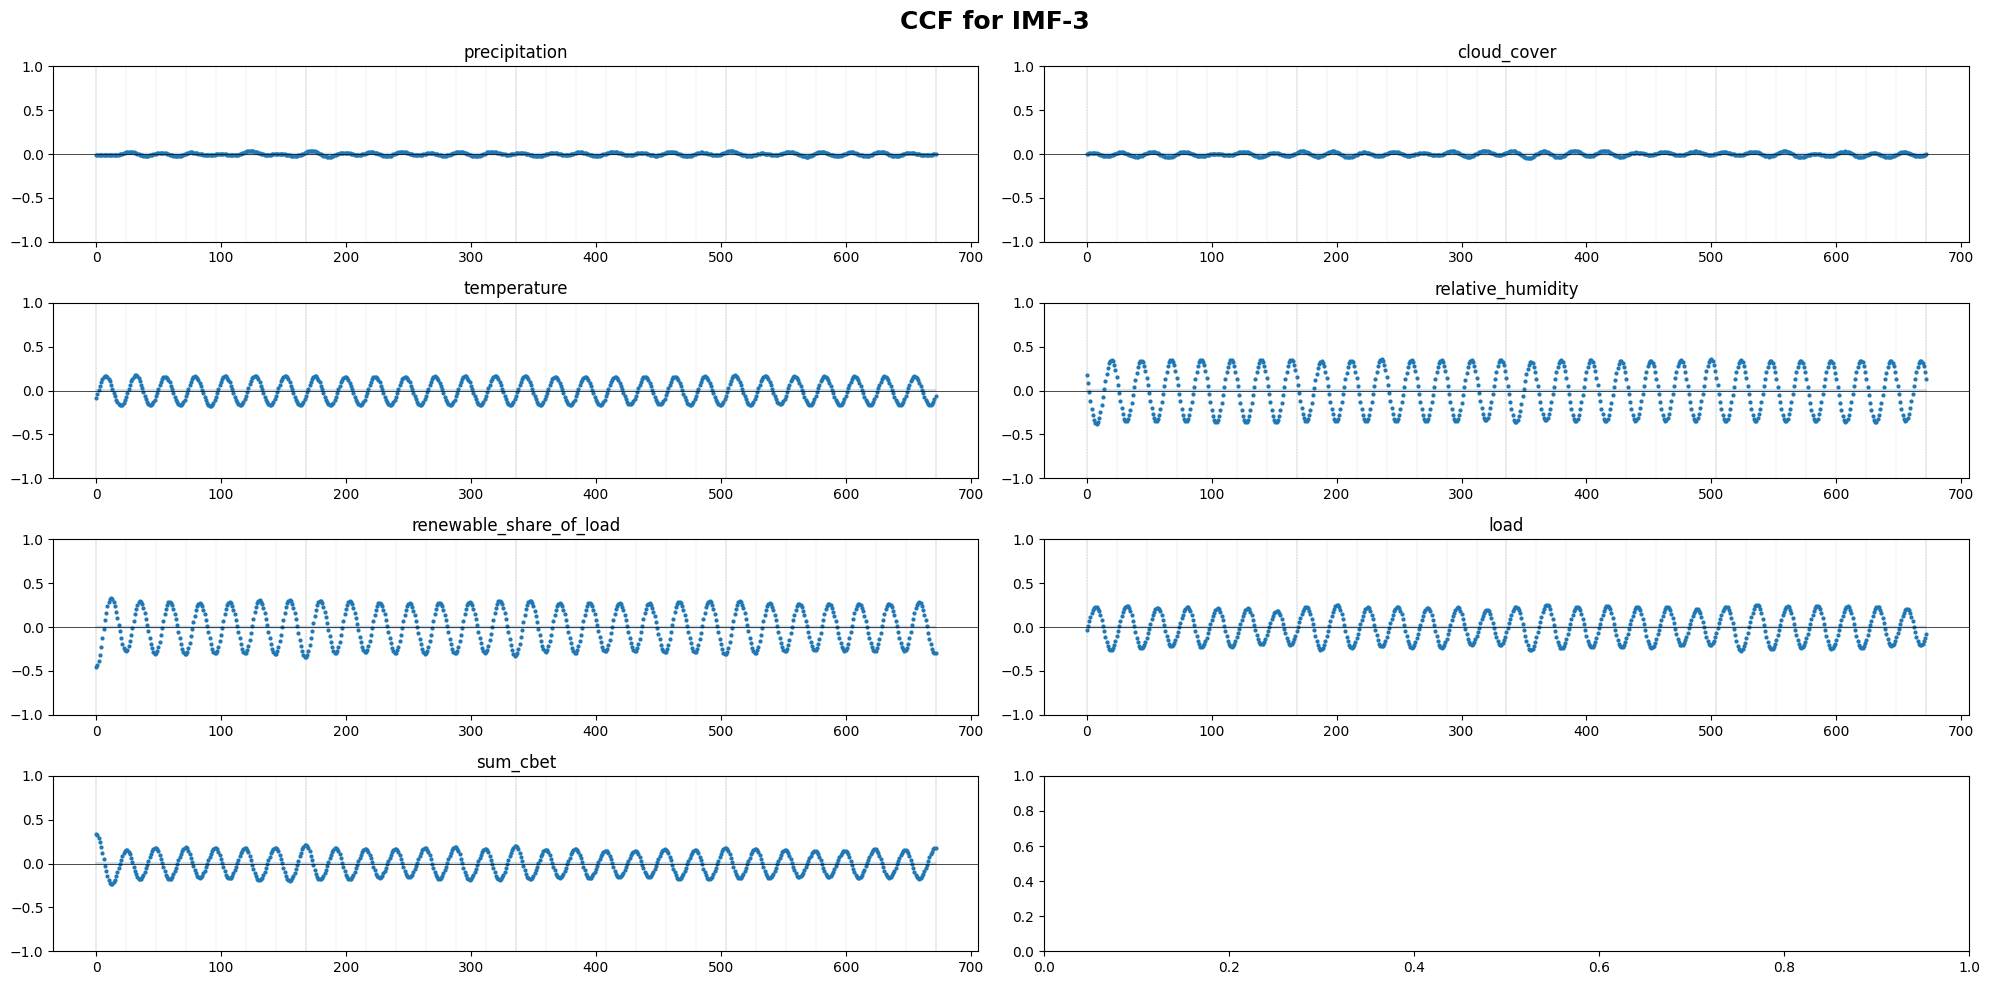

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


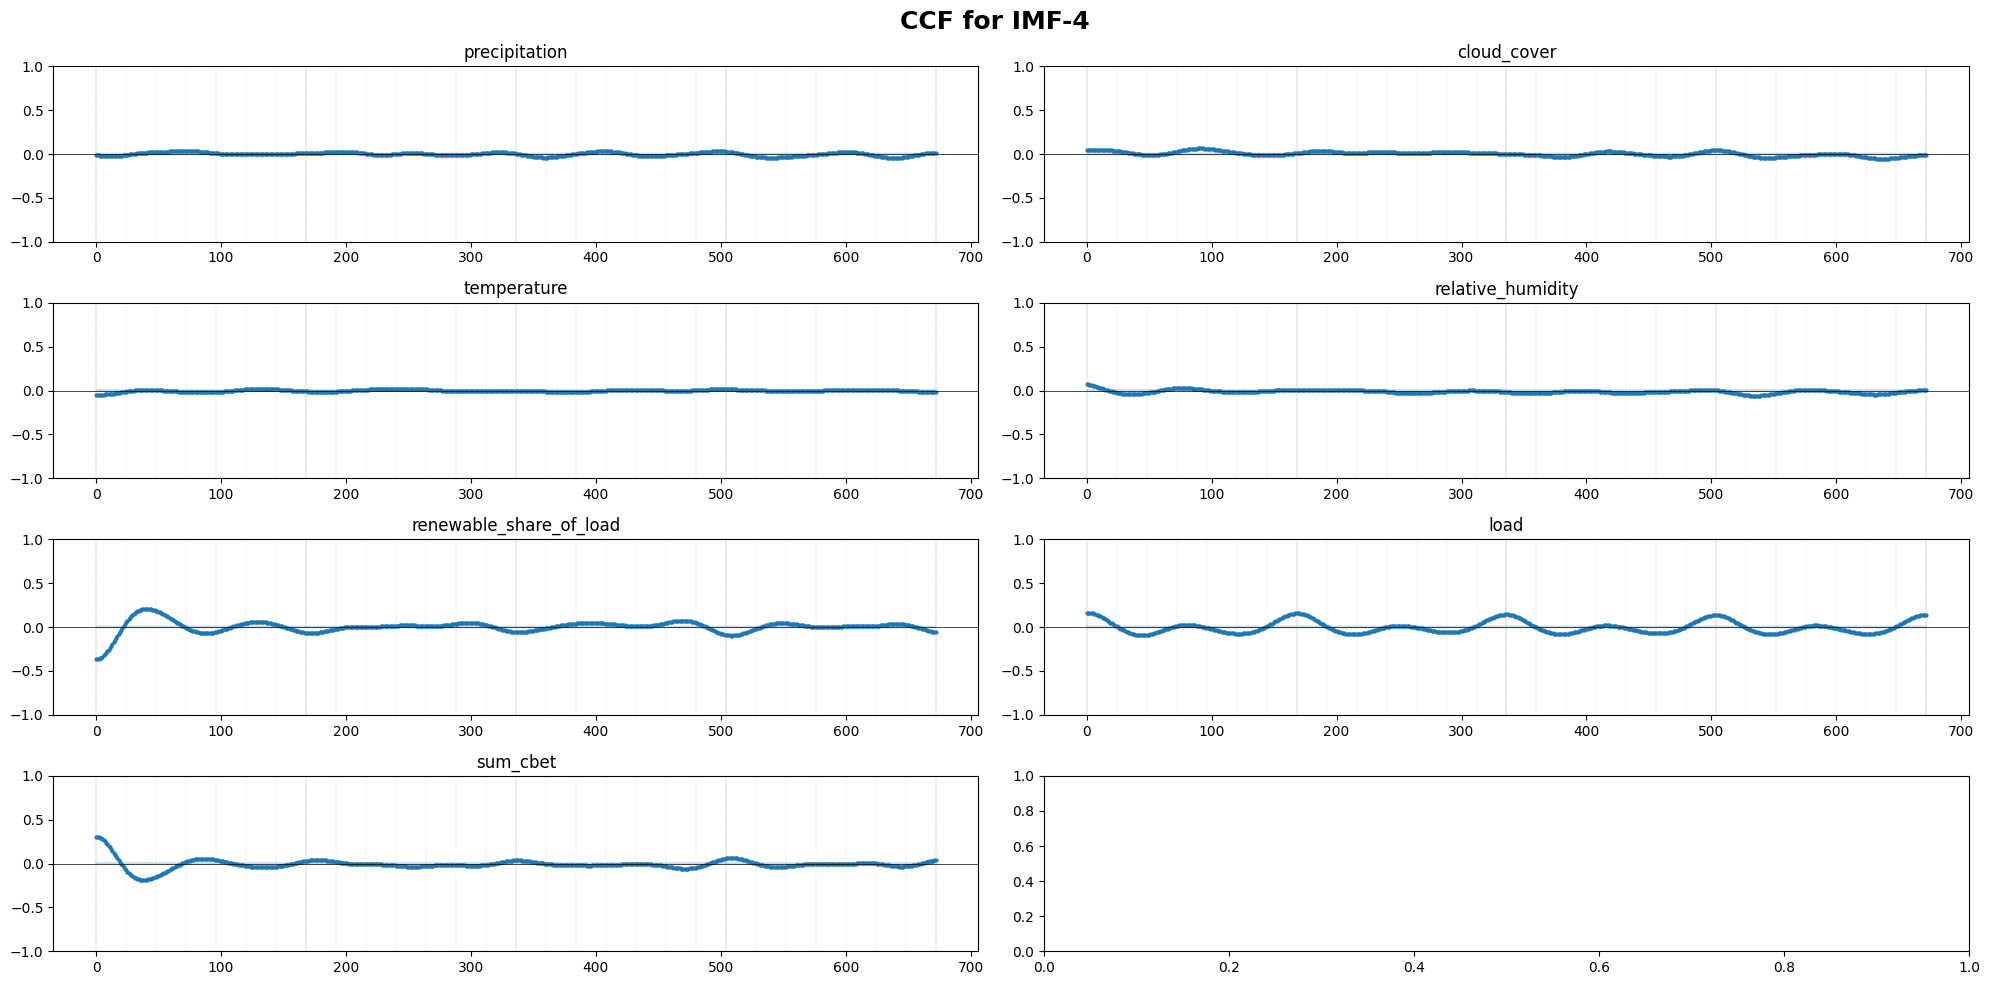

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


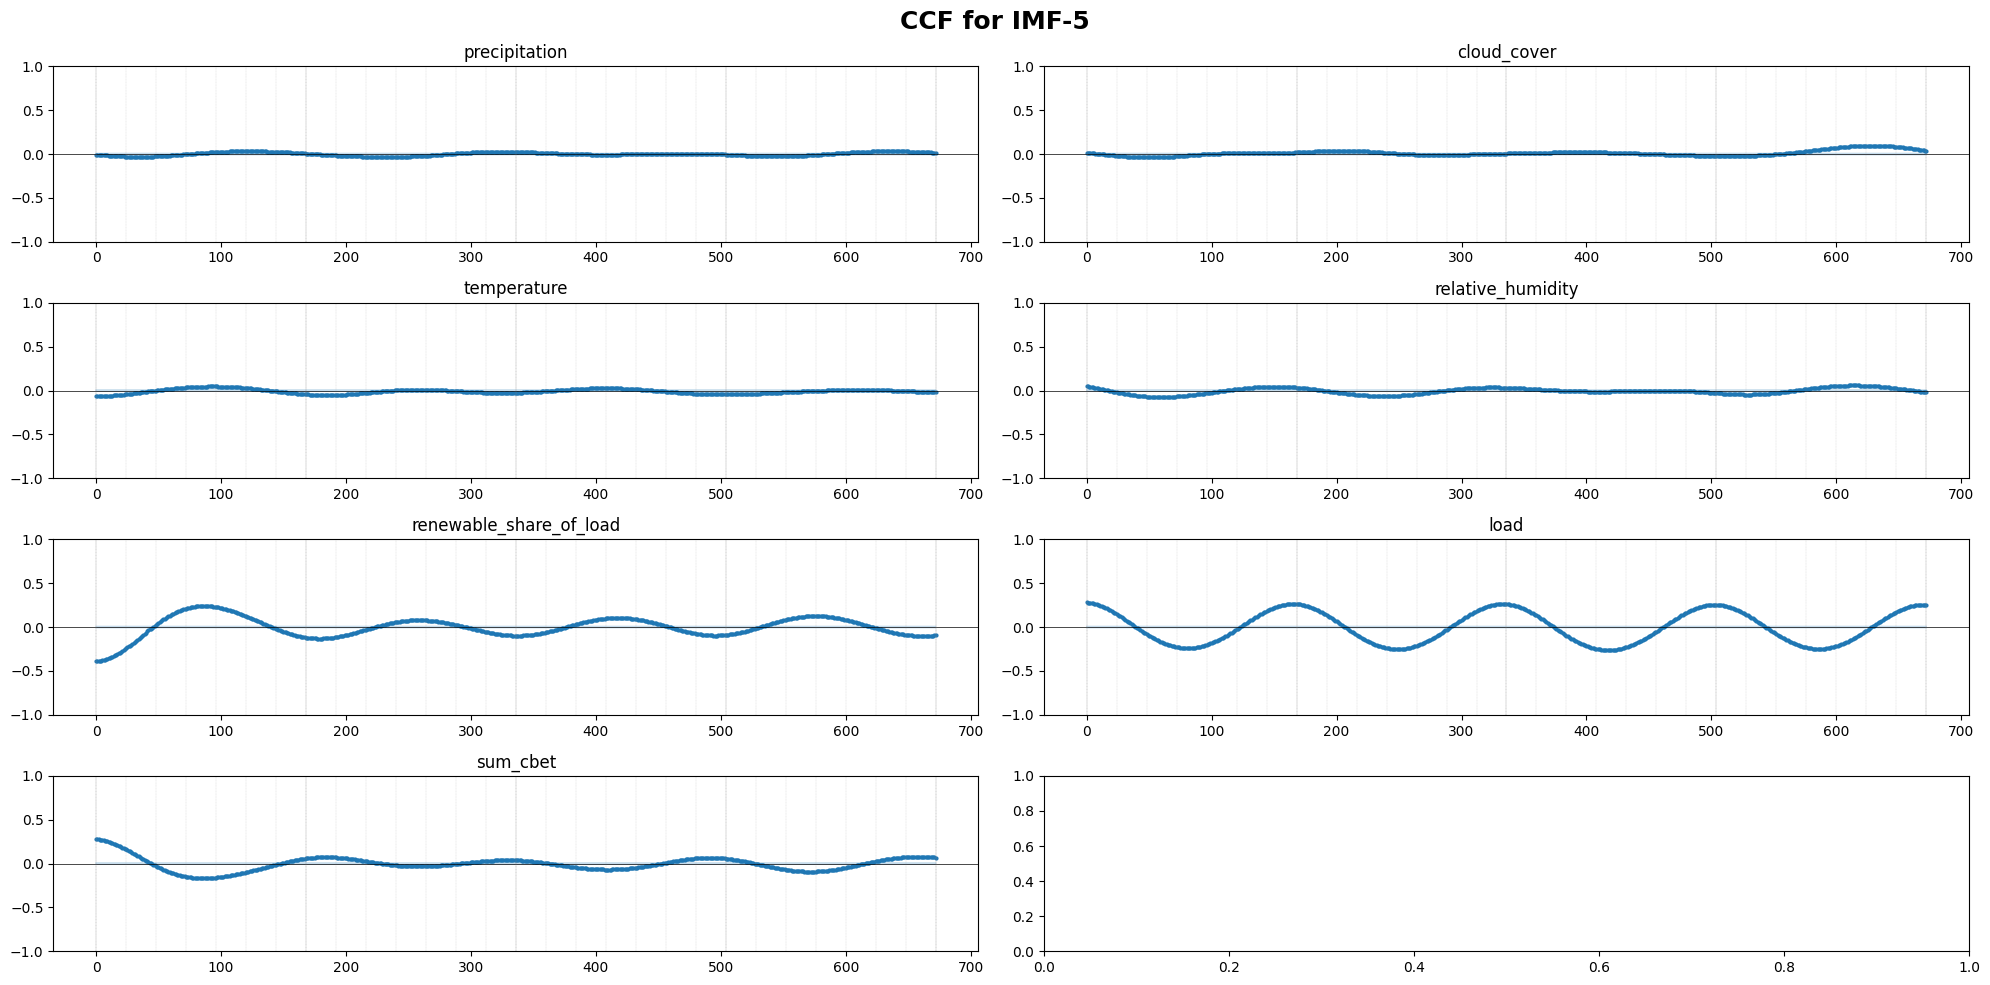

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


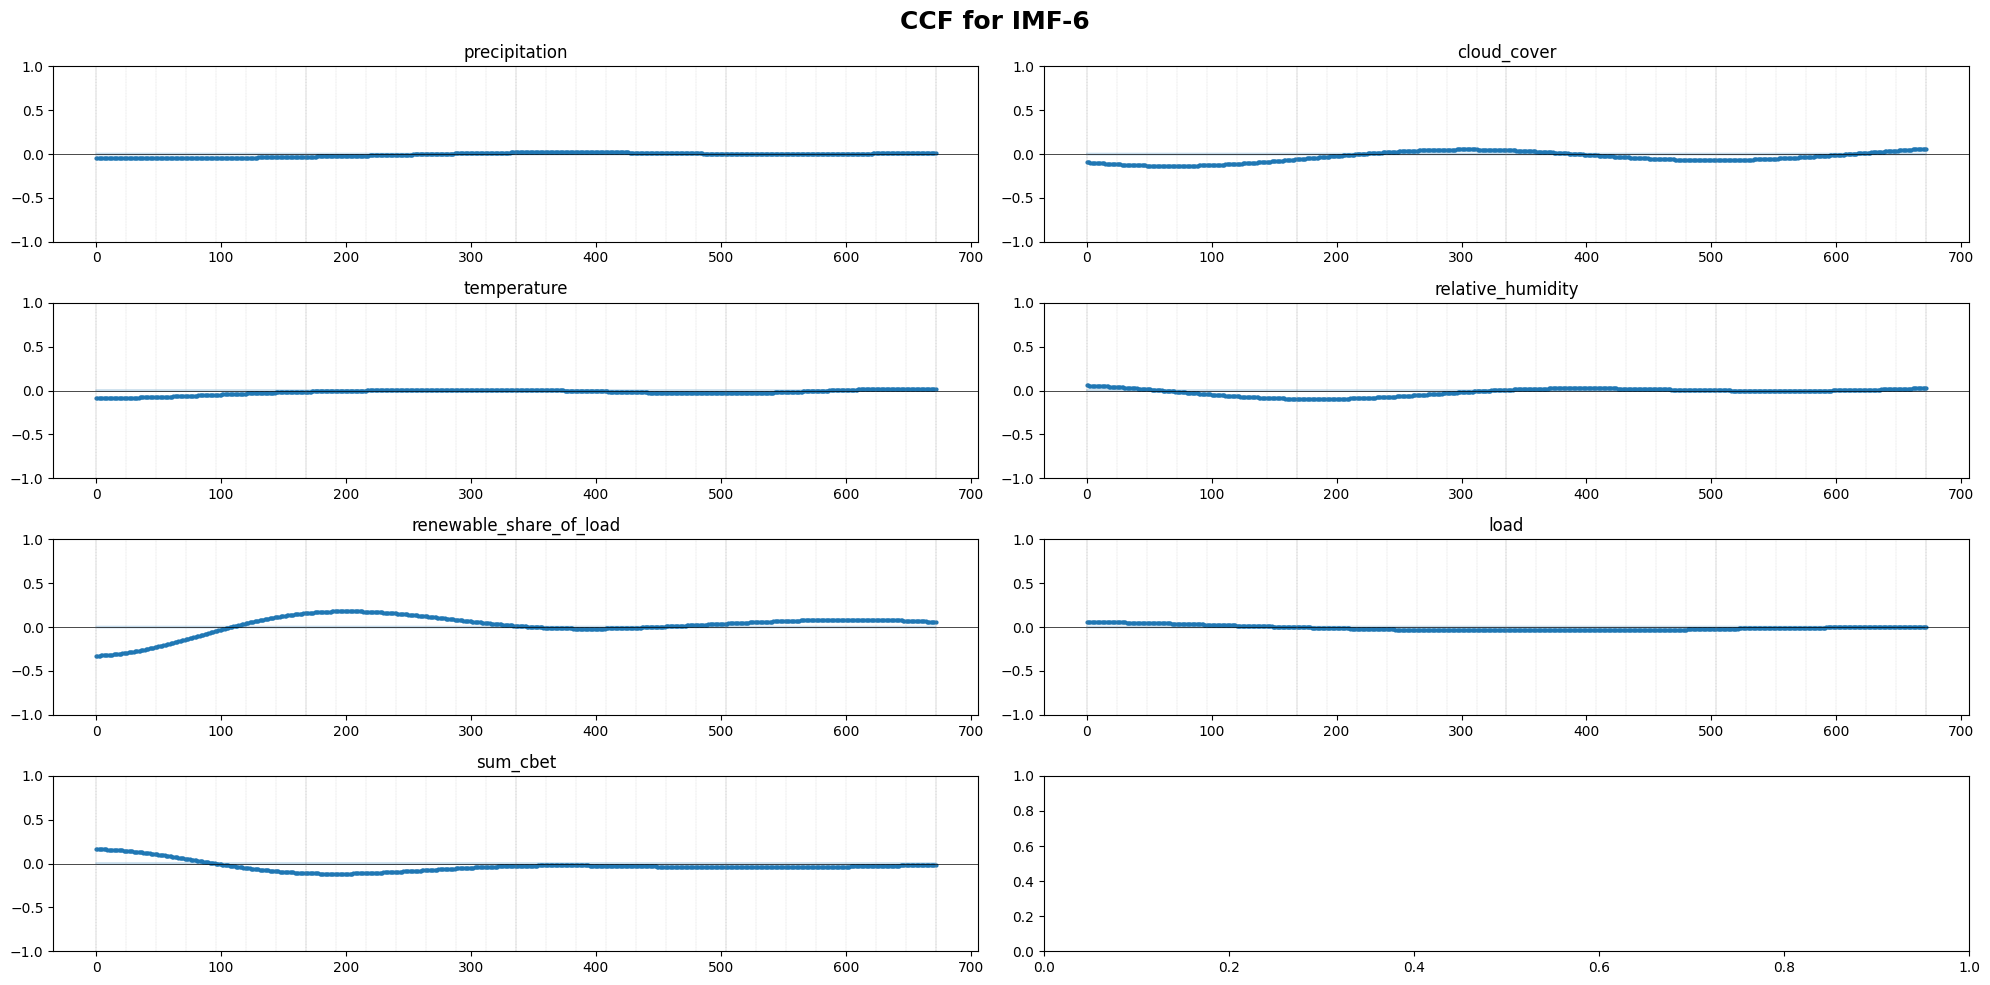

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


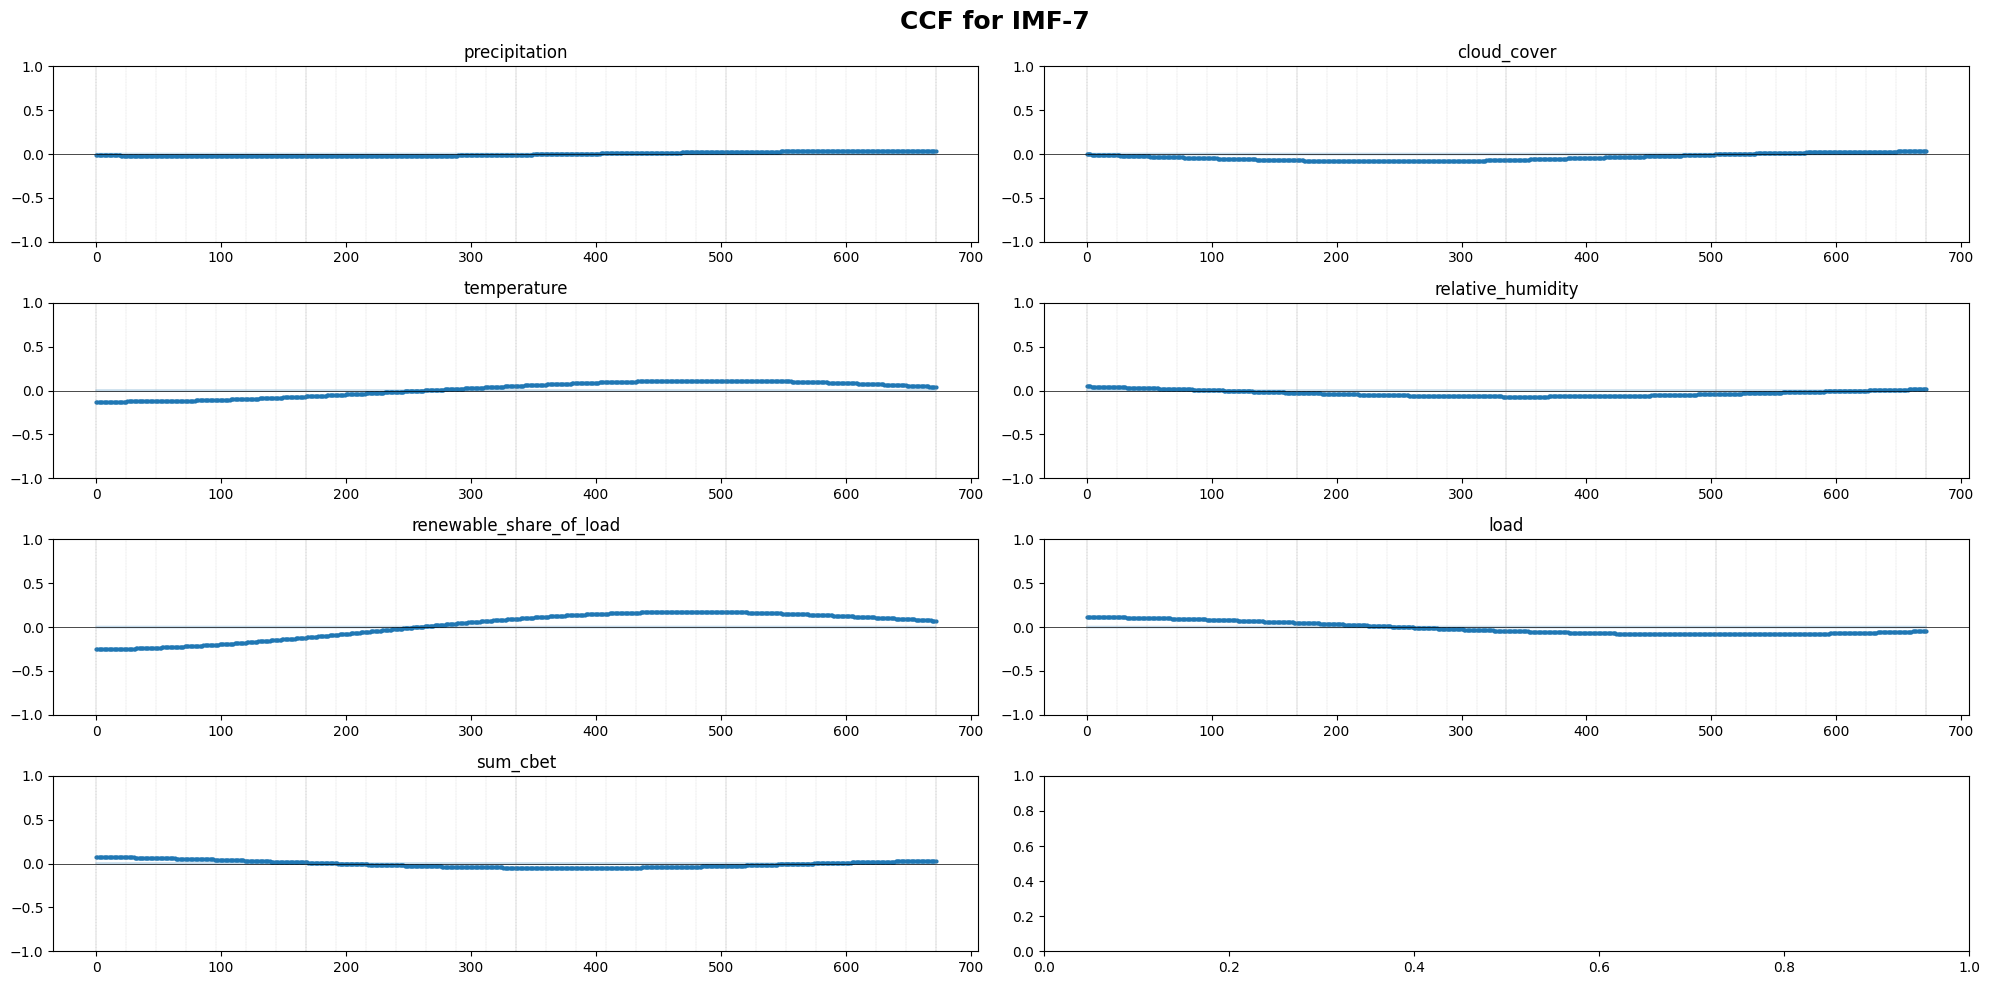

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


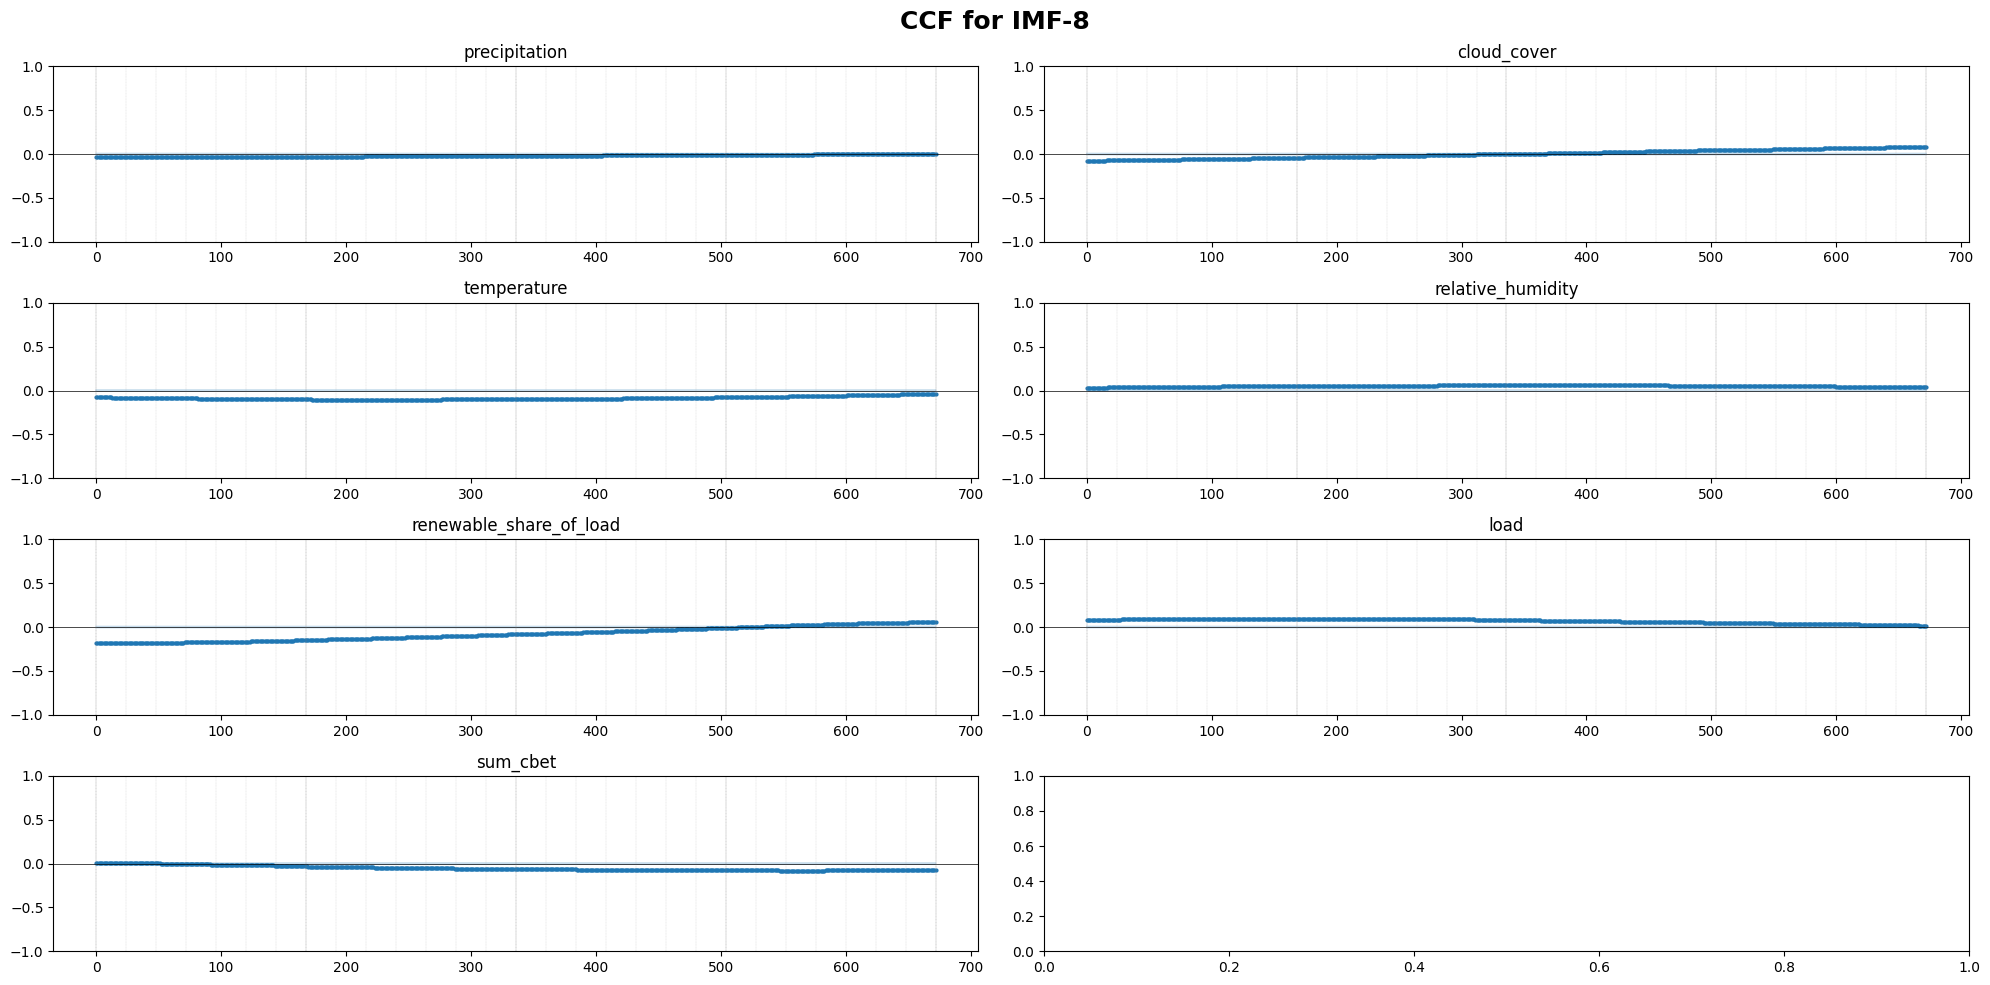

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


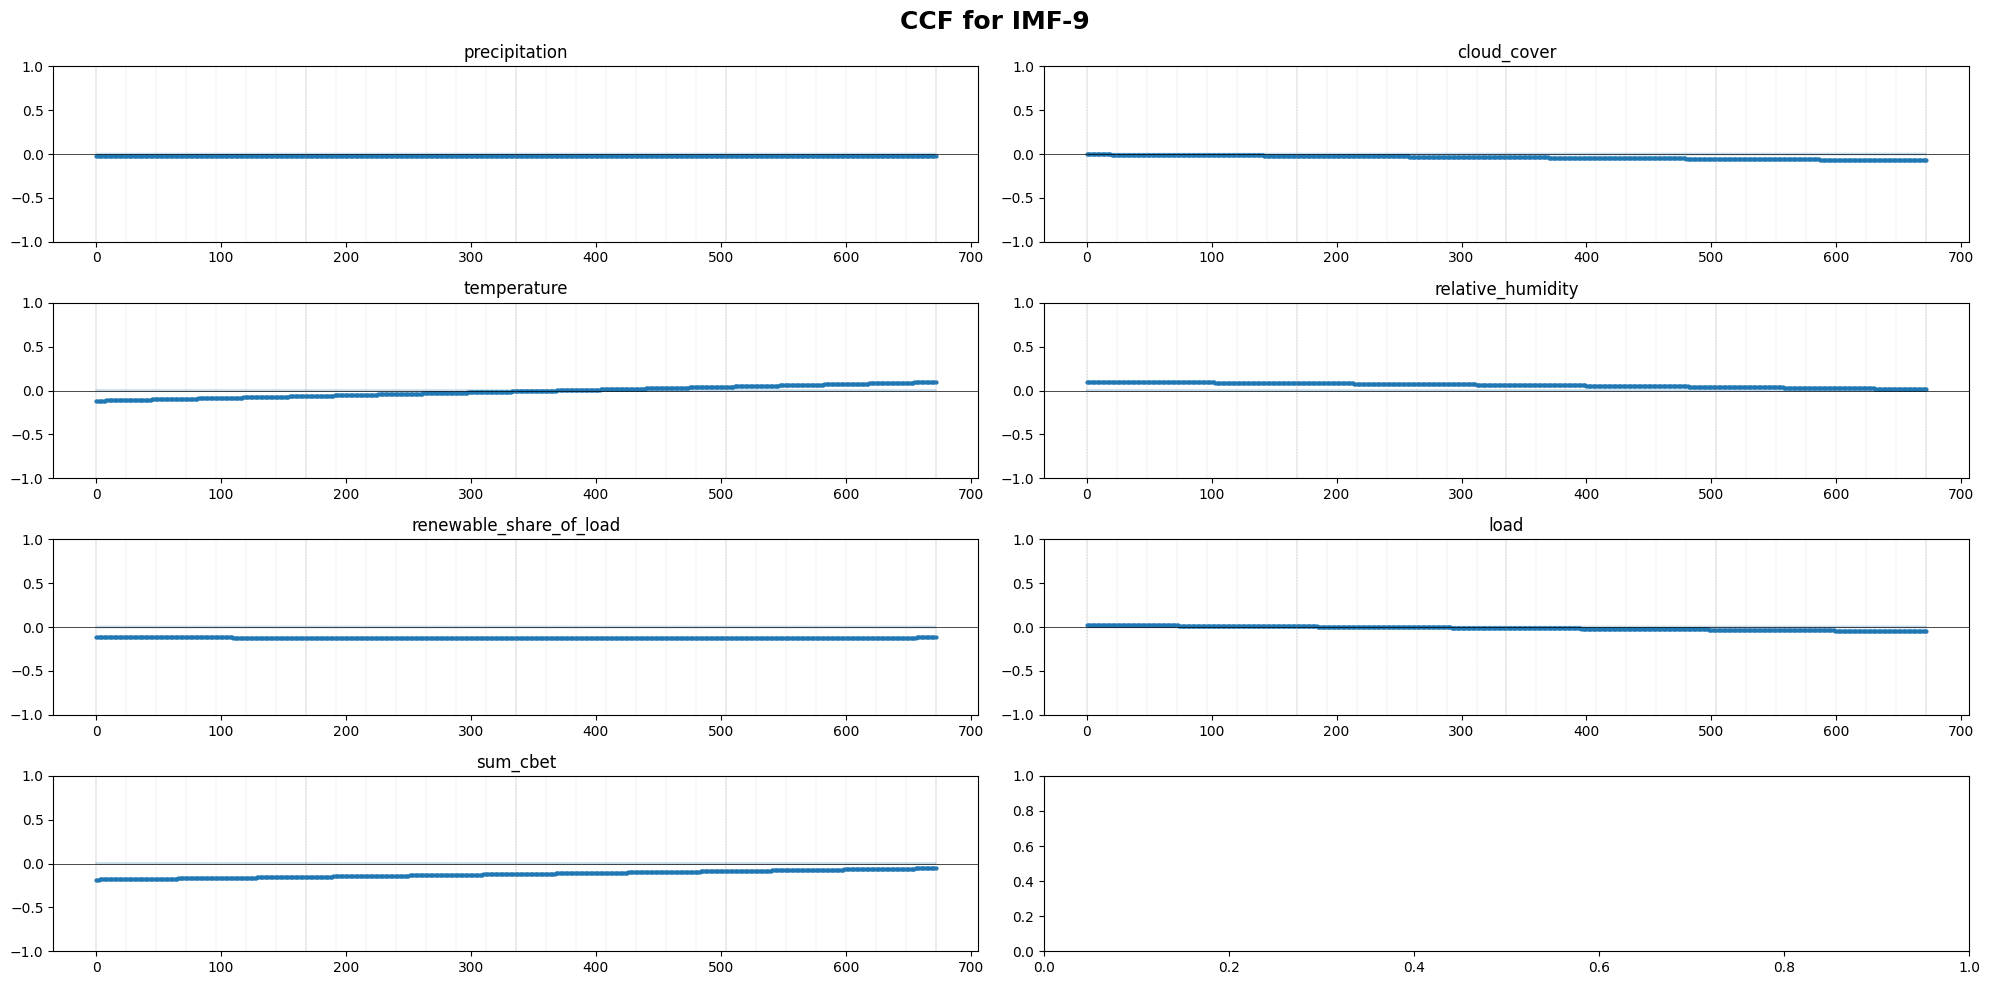

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [60]:
for i, dataset in enumerate(train_datasets):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 10))
    axes = axes.flatten()

    main_covar = [_ for _ in dataset.columns if 'datetime' not in _ and 'price' not in _]
    for j, col in enumerate(main_covar):
        ax = axes[j]
        plot_ccf(x=dataset[f'price_imf{i+1}'], y=dataset[col], alpha=0.05, ax=ax, lags=24*7*4, use_vlines=False, markersize=2)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.vlines([_ for _ in range(0, 24*7*4+1, 24)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle=':')
        ax.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], ymin=-1, ymax=1, color='gray', linewidth=0.2, linestyle='--')
        ax.set_title(col)

    fig.suptitle(f'CCF for IMF-{i+1}', fontweight='bold', fontsize=18)
    fig.tight_layout()
    plt.show()
    print('----'*64)

In [ ]:
# lagged exogenous for IMF-1
for l in [_ for _ in range(12, 24)] + [_ for _ in range(24, 24*7, 24)] + [_ for _ in range(24*7, 24*7*4, 24*7)]:
    train_data_imf1.loc[:, f'price_imf1_l{l}'] = train_data_imf1.loc[:, 'price_imf1'].shift(l)